[SAVE] results/expert_intervention_per_alg_alpha


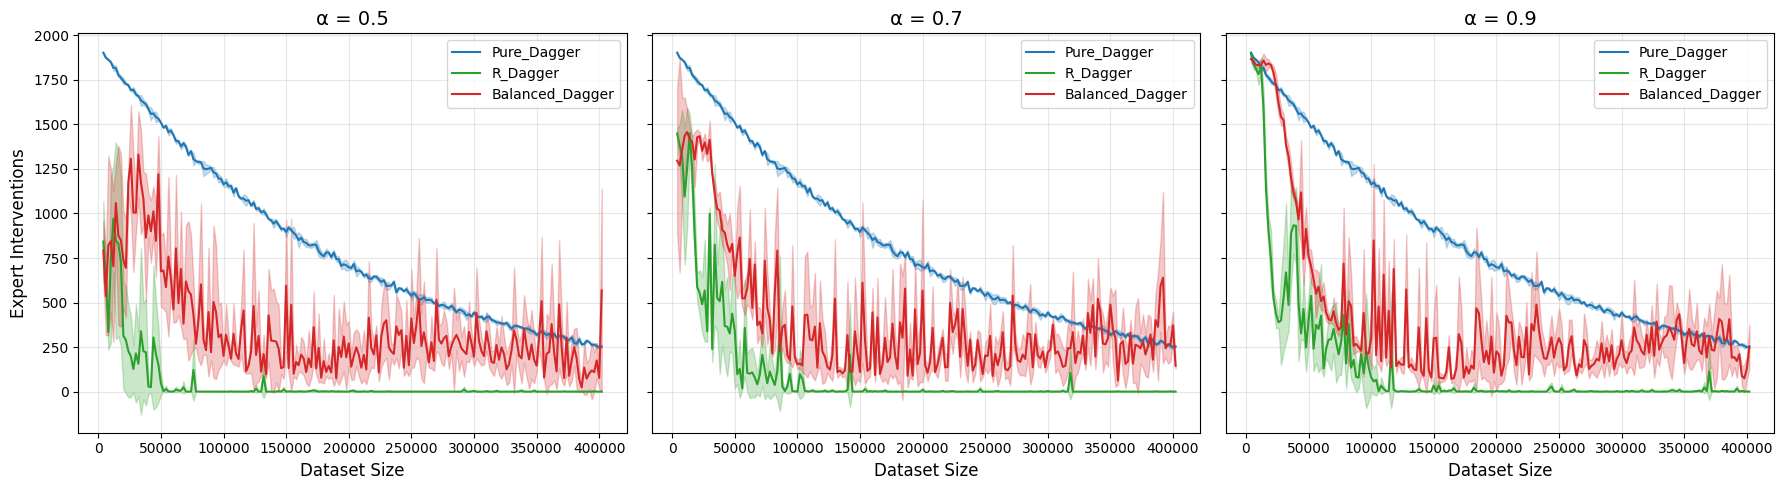

In [15]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt


# ----------------------------------------------
# Color map
# ----------------------------------------------
ALG_COLORS = {
    "Pure_Dagger": "tab:blue",
    "R_Dagger": "tab:green",
    "Balanced_Dagger": "tab:red",
    "Safe_Dagger": "tab:orange"}


# ------------------------------
# Load folders grouped by (ALG, alpha)
# ------------------------------
def load_all_experiments(total_root_dir):

    grouped = {}

    subfolders = [
        os.path.join(total_root_dir, d)
        for d in os.listdir(total_root_dir)
        if os.path.isdir(os.path.join(total_root_dir, d))
    ]

    for folder in subfolders:
        hyper_path = os.path.join(folder, "hyperparameters.json")
        results_path = os.path.join(folder, "results.json")

        if not os.path.exists(hyper_path) or not os.path.exists(results_path):
            continue

        with open(hyper_path, "r") as f:
            h = json.load(f)

        ALG = h["ALG"]
        alpha = h["alpha"]

        key = (ALG, alpha)
        grouped.setdefault(key, []).append(folder)

    return grouped


# ------------------------------
# Mean / Std
# ------------------------------
def compute_mean_std_for_group(folders):
    all_datasets = []
    all_nswitches = []

    for root in folders:
        with open(os.path.join(root, "results.json"), "r") as f:
            results = json.load(f)

        dataset_sizes = np.array(results["dataset_sizes"])
        nswitches = np.array(results["nswitches"])

        all_datasets.append(dataset_sizes)
        all_nswitches.append(nswitches)

    if len(all_nswitches) == 0:
        return None

    min_len = min(len(n) for n in all_nswitches)
    all_datasets = [d[:min_len] for d in all_datasets]
    all_nswitches = [n[:min_len] for n in all_nswitches]

    nswitch_stack = np.stack(all_nswitches, axis=0)

    mean = np.mean(nswitch_stack, axis=0)
    std = np.std(nswitch_stack, axis=0)
    dataset_ref = all_datasets[0]
    return dataset_ref, mean, std


# ------------------------------
# 1×3 subplot with Pure_Dagger fixed
# ------------------------------
def plot_by_alpha_row(grouped, save_path=None):
    if save_path is not None:
        os.makedirs(save_path, exist_ok=True)
    # Extract alpha list
    alphas = sorted(list({a for (_, a) in grouped.keys()}))

    fig, axes = plt.subplots(1, len(alphas), figsize=(18, 5), sharey=True)
    pure_groups = [folders for (ALG, a), folders in grouped.items() if ALG == "Pure_Dagger"]

    if len(pure_groups) == 0:
        print("[WARN] No Pure_Dagger found.")
        pure_data = None
    else:
        pure_data = compute_mean_std_for_group(pure_groups[0])   # 첫 번째 것만 사용

    # --------------------------------------------
    # Loop for each alpha subplot
    # --------------------------------------------
    for idx, alpha in enumerate(alphas):
        ax = axes[idx]
        ax.set_title(f"α = {alpha}", fontsize=14)

        # --- 1) ALWAYS draw Pure_Dagger ---
        if pure_data is not None:
            x, mean, std = pure_data
            ax.plot(x, mean, color=ALG_COLORS["Pure_Dagger"], label="Pure_Dagger")
            ax.fill_between(x, mean - std, mean + std,
                            color=ALG_COLORS["Pure_Dagger"], alpha=0.25)

        # --- 2) Other Algorithms (alpha-matched) ---
        for ALG in ["R_Dagger", "Balanced_Dagger", "Safe_Dagger"]:
            key = (ALG, alpha)
            if key not in grouped:
                continue

            result = compute_mean_std_for_group(grouped[key])
            if result is None:
                continue

            x, mean, std = result
            ax.plot(x, mean, color=ALG_COLORS[ALG], label=ALG)
            ax.fill_between(x, mean - std, mean + std,
                            color=ALG_COLORS[ALG], alpha=0.25)

        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Dataset Size", fontsize=12)
        if idx == 0:
            ax.set_ylabel("Expert Interventions", fontsize=12)

        ax.legend()

    plt.tight_layout()
    if save_path is not None:
        save_file = os.path.join(save_path, "expert_intervention_per_alg_alpha")
        plt.savefig(save_file, dpi=200)
        print(f"[SAVE] {save_file}")
    plt.show()
    


# ------------------------------
# MAIN
# ------------------------------
total_root = "/AILAB-summer-school-2025/checkpoints"
grouped = load_all_experiments(total_root)
plot_by_alpha_row(grouped, save_path="results")

In [16]:
import json
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 🔧 1) Exponential Moving Average (EMA)
# ============================================================
def ema_smooth(y, alpha=0.5):
    y = np.array(y, dtype=float)
    if len(y) == 0:
        return y
    y_smooth = np.zeros_like(y)
    y_smooth[0] = y[0]
    for i in range(1, len(y)):
        y_smooth[i] = alpha * y[i] + (1 - alpha) * y_smooth[i - 1]
    return y_smooth


# ============================================================
# 🔧 2) Core processing (Success / Reward 데이터 추출)
# ============================================================
def extract_algo_alpha_curves(algo_data):
    """algo_data = data[algo][alpha_key] 구조에서
       all_iters, success_mean_s, reward_mean_s, reward_var 반환"""

    seeds = algo_data["seeds"]

    # 전체 iteration 합집합
    all_iters = sorted({
        int(k)
        for seed_str in seeds
        for k in seeds[seed_str]["iter_results"].keys()
    })

    success_means = []
    reward_means = []
    reward_stds = []

    for it in all_iters:
        seed_succ = []
        seed_rew = []

        for seed_str, seed_entry in seeds.items():
            iter_results = seed_entry["iter_results"]
            if str(it) not in iter_results:
                continue

            r = iter_results[str(it)]
            succ_vals = r["success_list"][3:]     # skip first 3 eps
            rew_vals  = r["reward_list"][3:]

            seed_succ.append(np.mean(succ_vals))
            seed_rew.append(np.mean(rew_vals))

        if seed_succ:
            success_means.append(np.mean(seed_succ))
        else:
            success_means.append(np.nan)

        if seed_rew:
            reward_means.append(np.mean(seed_rew))
            reward_stds.append(0.5 * np.std(seed_rew))
        else:
            reward_means.append(np.nan)
            reward_stds.append(np.nan)

    # smoothing
    success_s = ema_smooth(success_means)
    reward_s  = ema_smooth(reward_means)

    return all_iters, success_s, reward_s, reward_stds


# ============================================================
# 🔧 3) Full plotting
# ============================================================
def plot_success_reward(json_path, save_path=None):
    if save_path is not None:
        os.makedirs(save_path, exist_ok=True)

    with open(json_path, "r") as f:
        data = json.load(f)

    algorithms = ["Pure_Dagger", "R_Dagger", "Balanced_Dagger", "Safe_Dagger"]

    colors = {
        "Pure_Dagger": "tab:blue",
        "R_Dagger": "tab:green",
        "Balanced_Dagger": "tab:red",
        "Safe_Dagger": "tab:orange"
    }

    # ------------------------------------------------------------
    # α 리스트
    # ------------------------------------------------------------
    alpha_list = sorted({
        float(alpha_key)
        for algo in data.values()
        for alpha_key in algo.keys()
        if alpha_key.replace('.', '', 1).isdigit()
    })

    # =================================================================
    # 🔥 Part 1: SUCCESS PLOT (only α=0.5)
    # =================================================================
    target_alpha = 0.5
    print(f"[INFO] Creating success plot for alpha={target_alpha}")

    fig_s, ax_s = plt.subplots(figsize=(7, 5))

    for algo in algorithms:

        if algo == "Pure_Dagger":
            # Pure는 첫 alpha 데이터 사용
            alpha_key = list(data[algo].keys())[0]
            iters, succ_s, _, _ = extract_algo_alpha_curves(data[algo][alpha_key])

        else:
            if str(target_alpha) not in data[algo]:
                continue
            iters, succ_s, _, _ = extract_algo_alpha_curves(data[algo][str(target_alpha)])

        ax_s.plot(iters, succ_s,
                  label=algo, color=colors[algo], linewidth=2)

    ax_s.set_title("Success Rate (α = 0.5)")
    ax_s.set_xlabel("Iteration")
    ax_s.set_ylabel("Success Rate")
    ax_s.grid(True, alpha=0.4)
    ax_s.legend()

    fig_s.tight_layout()
    fig_s.savefig(f"{save_path}/success_alpha0.5.png", dpi=200)
    plt.close(fig_s)

    print("[SAVE] success_alpha0.5.png")

    # =================================================================
    # 🔥 Part 2: REWARD PLOTS (α = 0.5, 0.7, 0.9) — horizontal subplots
    # =================================================================
    print("[INFO] Creating reward subplot row (1×3)")

    fig_r, axes = plt.subplots(
        nrows=1,
        ncols=len(alpha_list),
        figsize=(17, 5),
        sharey=True
    )

    for idx, alpha in enumerate(alpha_list):
        ax = axes[idx]
        ax.set_title(f"Reward (α = {alpha})")

        pure_alpha_key = list(data["Pure_Dagger"].keys())[0]
        iters, _, rew_s_pure, std_pure = extract_algo_alpha_curves(data["Pure_Dagger"][pure_alpha_key])

        ax.plot(iters, rew_s_pure,
                label="Pure_Dagger",
                color=colors["Pure_Dagger"],
                linewidth=2)
        ax.fill_between(iters,
                        np.array(rew_s_pure) - np.array(std_pure),
                        np.array(rew_s_pure) + np.array(std_pure),
                        color=colors["Pure_Dagger"], alpha=0.15)

        # Other algorithms for each alpha
        for algo in ["R_Dagger", "Balanced_Dagger", "Safe_Dagger"]:
            if str(alpha) not in data[algo]:
                continue

            iters, _, rew_s, stds = extract_algo_alpha_curves(data[algo][str(alpha)])
            ax.plot(iters, rew_s,
                    label=algo, color=colors[algo], linewidth=2)
            ax.fill_between(iters,
                            np.array(rew_s) - np.array(stds),
                            np.array(rew_s) + np.array(stds),
                            color=colors[algo], alpha=0.15)

        ax.set_xlabel("Iteration")
        ax.grid(True, alpha=0.3)
        if idx == 0:
            ax.set_ylabel("Reward")

    fig_r.legend(algorithms, loc="upper center", ncol=4)
    fig_r.tight_layout(rect=[0, 0, 1, 0.92])
    fig_r.savefig(f"{save_path}/reward_per_alg_alpha.png", dpi=200)
    plt.close(fig_r)

    print("[SAVE] reward_all_alpha.png")


# 실행
plot_success_reward(
    json_path="/AILAB-summer-school-2025/eval_all_iters.json",
    save_path="results"
)


[INFO] Creating success plot for alpha=0.5
[SAVE] success_alpha0.5.png
[INFO] Creating reward subplot row (1×3)
[SAVE] reward_all_alpha.png
